In [2]:
import xarray as xr
from glob import glob
from braceexpand import braceexpand
from dask.distributed import Client
from dask_jobqueue import SLURMCluster
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def braced_glob(path):
    l = []
    for x in braceexpand(path):
        l.extend(glob(x))          
    return l

In [3]:
contrib_ext = False
ext = False
sim = 'UBB'
iyear = 2017
var = 'pr'

if sim == 'ERA5':
    var_lat = 'latitude'
    var_lon = 'longitude'
else:
    var_lat = 'rlat'
    var_lon = 'rlon'

if var == 'pr':
    name_var = 'pr'
    folder_var = 'PR'
    file_var = 'pr'
elif var == 'ws':
    name_var = 'surf_wind'
    if sim == 'ERA5':
        folder_var = 'WIND/Magnitude'
    else:
        folder_var = 'WIND'
    file_var = 'wind10'

if ext and contrib_ext:
    raise ValueError("Cannot use both --ext and --contrib_ext at the same time. Choose one.")
if ext:
    ext_str = 'extreme_'
else:
    ext_str = ''

In [4]:
if sim == 'ERA5':
    if var == 'pr':
        filenames_var = f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/{folder_var}/{sim.lower()}_tp_CORDEX_NA_1979-2023.zarr'
    elif var == 'ws':
        filenames_var = f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/{folder_var}/{sim.lower()}_{file_var}_CORDEX_NA_1979-2023.zarr'
    ds_var = xr.open_zarr(filenames_var)
    if var == 'pr': ds_var = ds_var.rename({'tp': 'pr'})
else:
    filenames_var = braced_glob(f"/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/{folder_var}/{file_var}_{sim.lower()}_{iyear}*_se.nc")
    ds_var = xr.open_mfdataset(filenames_var)
    if var == 'pr':
        ds_var = ds_var.drop_vars(['rotated_pole', 'time_bnds']).squeeze('height', drop=True)
        ds_var['time'] = ds_var['time'].dt.floor('h')
    elif var == 'ws':
        ds_var['time'] = ds_var['time'].dt.round('h')

filenames_ETCs = braced_glob(f"/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/{folder_var}/1000km_storm/{file_var}_{sim.lower()}_{iyear}*_1000km_{ext_str}storm.nc")
ds_ETCs = xr.open_mfdataset(filenames_ETCs)

if ext:
    ds_ETCs = ds_ETCs.chunk({var_lat: -1, var_lon: -1, 'time': 100, 'quantile': 1})
else:
    ds_ETCs = ds_ETCs.chunk({var_lat: -1, var_lon: -1, 'time': 100})
ds_var = ds_var.chunk({var_lat: -1, var_lon: -1, 'time': 100})

ds_ETCs['season'] = ds_ETCs['time'].dt.season
ds_var['season'] = ds_var['time'].dt.season

ds_ETCs

<xarray.Dataset> Size: 15GB
Dimensions:  (time: 8760, rlat: 655, rlon: 655)
Coordinates:
    lat      (rlat, rlon) float64 3MB dask.array<chunksize=(655, 655), meta=np.ndarray>
    lon      (rlat, rlon) float64 3MB dask.array<chunksize=(655, 655), meta=np.ndarray>
  * rlat     (rlat) float64 5kB -34.62 -34.51 -34.4 -34.28 ... 37.1 37.22 37.33
  * rlon     (rlon) float64 5kB -31.85 -31.74 -31.62 -31.51 ... 39.88 39.99 40.1
  * time     (time) datetime64[ns] 70kB 2017-01-01 ... 2017-12-31T23:00:00
Data variables:
    pr       (time, rlat, rlon) float32 15GB dask.array<chunksize=(100, 655, 655), meta=np.ndarray>
    season   (time) <U3 105kB 'DJF' 'DJF' 'DJF' 'DJF' ... 'DJF' 'DJF' 'DJF'

In [5]:
%%time
ds_ETCs = ds_ETCs.compute()
ds_var = ds_var.compute()

CPU times: user 1min 22s, sys: 17.2 s, total: 1min 39s
Wall time: 3min 24s


In [7]:
%%time
if contrib_ext:
    if var == 'pr':
        percentile = xr.open_dataset(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/PR_Percentile/pr_{sim.lower()}_percentile.nc')
    elif var == 'ws':
        percentile = xr.open_dataset(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/WIND_Percentile/surf_wind_{sim.lower()}_percentile.nc')

    mask_ETCs_ext = ds_ETCs.where(ds_ETCs >= percentile, np.nan) #FAIRE UN CHECK DES UNITÉS
    mask_var_ext = ds_var.where(ds_var >= percentile, np.nan)    #FAIRE UN CHECK DES UNITÉS

    for season in ['DJF']:#, 'MAM', 'JJA', 'SON']:
        mask_ETCs_ext_season = mask_ETCs_ext.where(mask_ETCs_ext['season'] == season, drop=True) #le cumul au dessus du seuil, quand on est à - de 1000km d'un ETC, pour la saison season
        mask_var_ext_season = mask_var_ext.where(mask_var_ext['season'] == season, drop=True)

        sum_ETCs = mask_ETCs_ext_season[name_var].sum(dim='time')
        sum_var = mask_var_ext_season[name_var].sum(dim='time')

        count_ETCs = mask_ETCs_ext_season.where(mask_ETCs_ext_season[name_var] > 0.)[name_var].count(dim='time')
        count_ext = mask_var_ext_season.where(mask_var_ext_season.pr > 0.)[name_var].count(dim='time')
        
else:
    for season in ['DJF']:#, 'MAM', 'JJA', 'SON']:

        ds_ETCs_season = ds_ETCs.where(ds_ETCs['season'] == season, drop=True)
        ds_var_season = ds_var.where(ds_var['season'] == season, drop=True)

        sum_ETCs = ds_ETCs_season[name_var].sum(dim='time')
        sum_var = ds_var_season[name_var].sum(dim='time')

        count_ETCs = ds_ETCs_season.where(ds_ETCs_season[name_var] > 0.)[name_var].count(dim='time')
        count_var = ds_var_season.where(ds_var_season[name_var] > 0.)[name_var].count(dim='time')

CPU times: user 22.7 s, sys: 9.34 s, total: 32 s
Wall time: 32.3 s


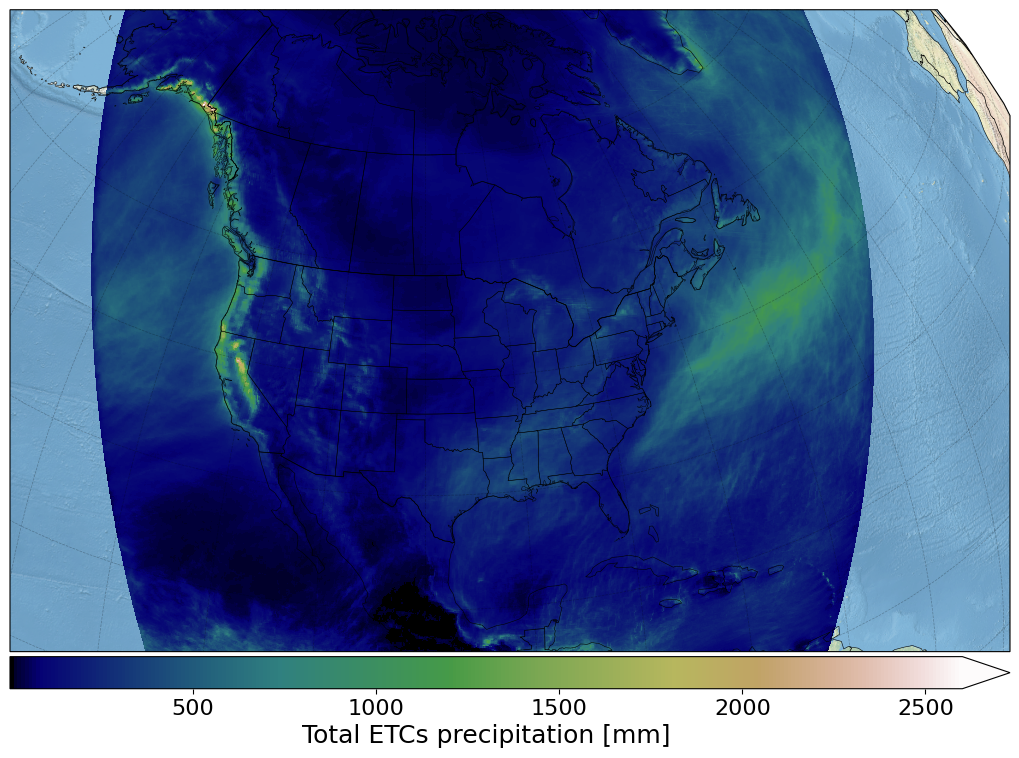

In [12]:
for_pole = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR/pr_ubb_199102_se.nc')
pole_lon = for_pole.rotated_pole.attrs['grid_north_pole_longitude']
pole_lat = for_pole.rotated_pole.attrs['grid_north_pole_latitude']
polecrs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(10,10), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-140, -35, 65, 15], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

cmap = plt.get_cmap('gist_earth')

crs = polecrs

# sc = ax.contourf(contrib_wind_EETCs_UBB.rlon, contrib_wind_EETCs_UBB.rlat, contrib_wind_EETCs_UBB.isel(quantile=2).surf_wind,
#                  levels=np.linspace(vmin, vmax, int((vmax-vmin)/5)+1), extend='max', cmap=cmap, transform=crs)

sc = ax.pcolormesh(sum_var.rlon, sum_var.rlat, sum_var*3600, cmap=cmap, transform=crs)

cb = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, aspect=40, extend='max')
cb.ax.tick_params(labelsize=16)
cb.set_label('Total ETCs precipitation [mm]', fontsize=18)

In [3]:
test = xr.open_dataset(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR/1000km_storm/total_pr_ubb_1000km_DJF_2019.nc')
test ##que pour 2019

<xarray.Dataset> Size: 9MB
Dimensions:  (rlat: 655, rlon: 655)
Coordinates:
    lat      (rlat, rlon) float64 3MB ...
    lon      (rlat, rlon) float64 3MB ...
  * rlat     (rlat) float64 5kB -34.62 -34.51 -34.4 -34.28 ... 37.1 37.22 37.33
  * rlon     (rlon) float64 5kB -31.85 -31.74 -31.62 -31.51 ... 39.88 39.99 40.1
Data variables:
    pr       (rlat, rlon) float32 2MB ...

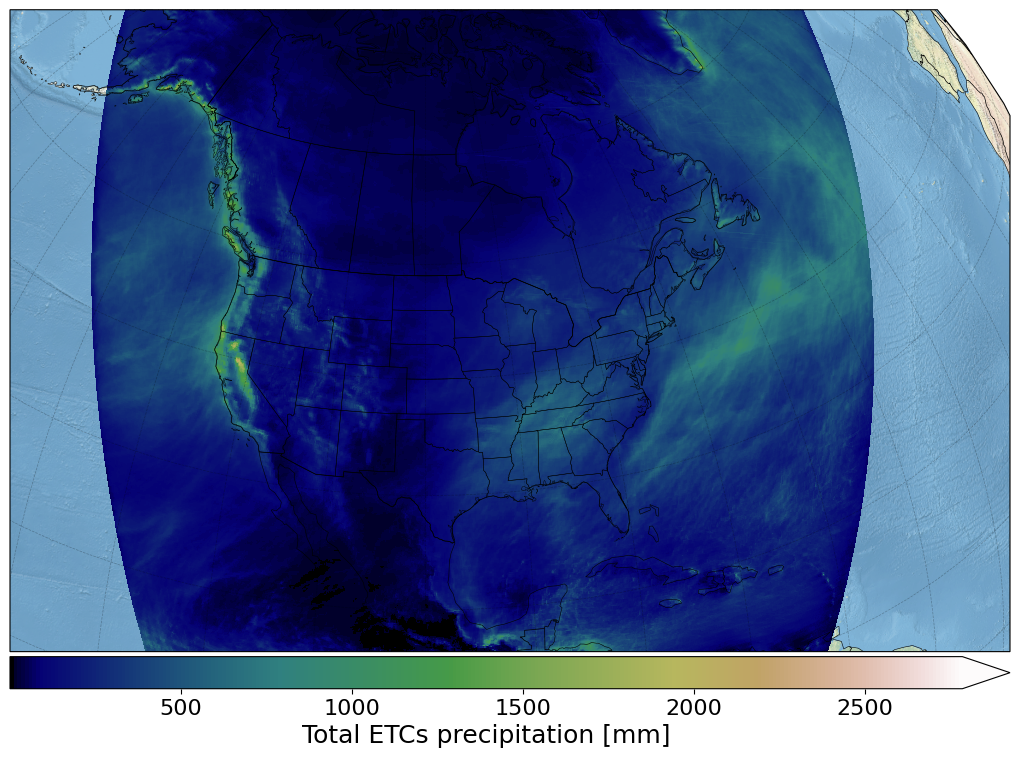

In [5]:
for_pole = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR/pr_ubb_199102_se.nc')
pole_lon = for_pole.rotated_pole.attrs['grid_north_pole_longitude']
pole_lat = for_pole.rotated_pole.attrs['grid_north_pole_latitude']
polecrs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(10,10), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-140, -35, 65, 15], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

cmap = plt.get_cmap('gist_earth')

crs = polecrs

# sc = ax.contourf(contrib_wind_EETCs_UBB.rlon, contrib_wind_EETCs_UBB.rlat, contrib_wind_EETCs_UBB.isel(quantile=2).surf_wind,
#                  levels=np.linspace(vmin, vmax, int((vmax-vmin)/5)+1), extend='max', cmap=cmap, transform=crs)

sc = ax.pcolormesh(test.rlon, test.rlat, test.pr*3600, cmap=cmap, transform=crs)

cb = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, aspect=40, extend='max')
cb.ax.tick_params(labelsize=16)
cb.set_label('Total ETCs precipitation [mm]', fontsize=18)

In [8]:
test_ext = xr.open_dataset(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR/1000km_storm/total_pr_ext_ubb_1000km_DJF_2019.nc')
test_ext ##que pour 2019

<xarray.Dataset> Size: 14MB
Dimensions:   (rlat: 655, rlon: 655, quantile: 4)
Coordinates:
    lat       (rlat, rlon) float64 3MB ...
    lon       (rlat, rlon) float64 3MB ...
  * rlat      (rlat) float64 5kB -34.62 -34.51 -34.4 -34.28 ... 37.1 37.22 37.33
  * rlon      (rlon) float64 5kB -31.85 -31.74 -31.62 ... 39.88 39.99 40.1
  * quantile  (quantile) float64 32B 0.98 0.99 0.995 0.999
Data variables:
    pr        (rlat, rlon, quantile) float32 7MB ...

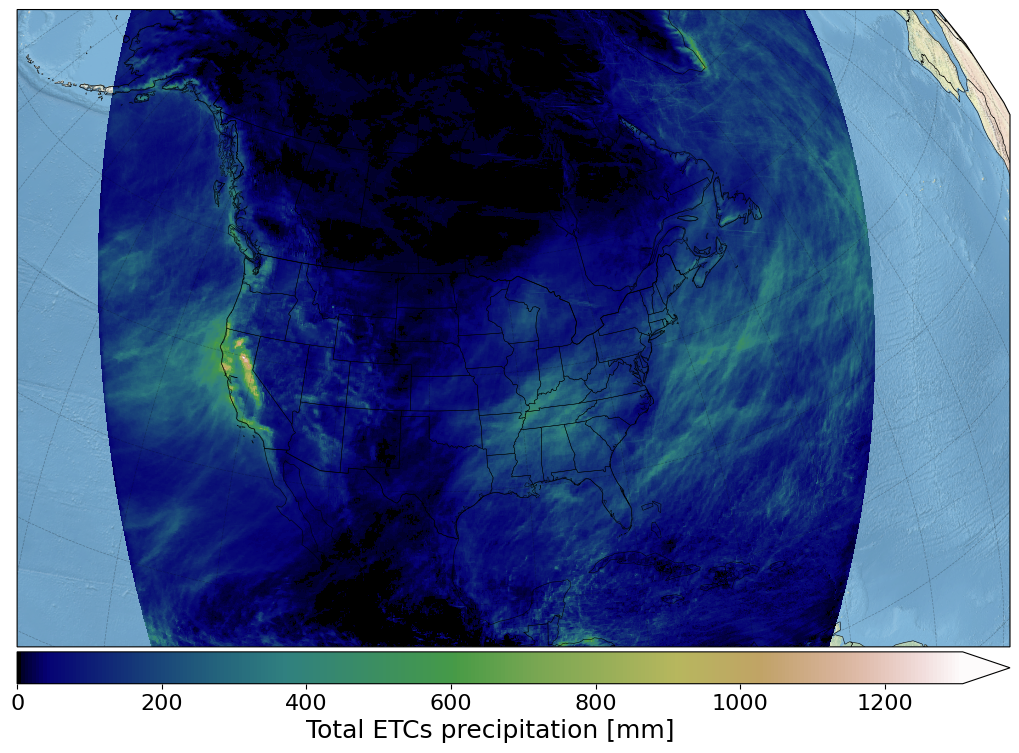

In [9]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(10,10), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-140, -35, 65, 15], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

cmap = plt.get_cmap('gist_earth')

crs = polecrs

# sc = ax.contourf(contrib_wind_EETCs_UBB.rlon, contrib_wind_EETCs_UBB.rlat, contrib_wind_EETCs_UBB.isel(quantile=2).surf_wind,
#                  levels=np.linspace(vmin, vmax, int((vmax-vmin)/5)+1), extend='max', cmap=cmap, transform=crs)

sc = ax.pcolormesh(test_ext.rlon, test_ext.rlat, test_ext.isel(quantile=0).pr*3600, cmap=cmap, transform=crs)

cb = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, aspect=40, extend='max')
cb.ax.tick_params(labelsize=16)
cb.set_label('Total ETCs precipitation [mm]', fontsize=18)